In [1]:
# ============================================================
# 1. Set up Spark Session
# ============================================================

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Seattle911_XGB_5fold")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/21 14:16:19 WARN Utils: Your hostname, Phongs-MacBook-Pro-23.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.46 instead (on interface en0)
25/11/21 14:16:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 14:16:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# ============================================================
# 2. Data Import
# ============================================================

import os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve().parents[1]

data_path = PROJECT_ROOT / "data" / "processed" / "calldata_20251019_processed_v4.csv"

df = spark.read.csv(str(data_path), header=True, inferSchema=True)
print(f"Loaded {df.count():,} rows with {len(df.columns)} columns")

Loaded 583,022 rows with 54 columns


In [3]:
# ============================================================
# 3. Data Filtering and Feature Setup
# ============================================================
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor

label_col = "call_sign_total_service_time_s"

df = (
    df.filter(F.col(label_col).isNotNull())
      .filter(
          (F.col("dispatch_neighborhood").isNotNull()) &
          (F.col("dispatch_sector").isNotNull()) &
          (F.col("dispatch_latitude").isNotNull()) &
          (F.col("dispatch_longitude").isNotNull()) &
          (~F.col("dispatch_neighborhood").like("%REDACTED%")) &
          (~F.col("dispatch_sector").like("%REDACTED%")) &
          (~F.col("dispatch_latitude").like("%REDACTED%")) &
          (~F.col("dispatch_longitude").like("%REDACTED%"))
      )
)

ts = F.col("cad_event_original_time_queued_datetime")

df = (
    df
    # hour and month
    .withColumn("cad_event_original_time_queued_datetime_hour",  F.hour(ts))
    .withColumn("cad_event_original_time_queued_datetime_month", F.month(ts))

    # day-of-week (string, e.g., Mon/Tue/…)
    .withColumn("cad_event_original_time_queued_datetime_dow",   F.date_format(ts, "E"))

    # day-of-week (numeric 1=Mon … 7=Sun)
    # Spark dayofweek(): 1=Sun … 7=Sat → remap to 1=Mon … 7=Sun
    .withColumn(
        "cad_event_original_time_queued_datetime_dow_num",
        ((F.dayofweek(ts) + 5) % 7 + 1).cast("int")
    )
)

raw_feats = [
    "priority",
    "call_type",
    "dispatch_neighborhood",
    "dispatch_sector",
    "dispatch_latitude",
    "dispatch_longitude",
    "cad_event_original_time_queued_datetime_hour",
    "cad_event_original_time_queued_datetime_dow_num",
    "cad_event_original_time_queued_datetime_month",
    "count_of_officers",
    "pseudo_priority_score",
]

num_feats = [
    "cad_event_original_time_queued_datetime_hour",
    "cad_event_original_time_queued_datetime_dow_num",
    "cad_event_original_time_queued_datetime_month",
    "count_of_officers",
    "pseudo_priority_score",      
    "dispatch_latitude",
    "dispatch_longitude",
    "priority"   
]

cat_feats = ["call_type", "dispatch_neighborhood", "dispatch_sector"]

def to_d(c):
    return F.coalesce(F.col(c).cast("double"), F.lit(0.0))


#### Correlation check

In [4]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.functions as F

# Select only numeric columns (ensure they're double)
for c in num_feats:
    df = df.withColumn(c, F.col(c).cast("double"))

# Assemble into feature vector
assembler = VectorAssembler(inputCols=num_feats, outputCol="num_vector")
corr_df = assembler.transform(df).select("num_vector")

# Compute Pearson correlation matrix
corr_mat = Correlation.corr(corr_df, "num_vector", method="pearson").collect()[0][0]

# Convert to numpy / pandas for readability
import numpy as np
import pandas as pd

corr_array = np.array(corr_mat.toArray())
corr_pd = pd.DataFrame(corr_array, columns=num_feats, index=num_feats)
print("=== Pearson Correlation Matrix ===")
display(corr_pd.style.background_gradient(cmap="coolwarm").format("{:.2f}"))

25/11/21 14:16:28 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


=== Pearson Correlation Matrix ===


,cad_event_original_time_queued_datetime_hour,cad_event_original_time_queued_datetime_dow_num,cad_event_original_time_queued_datetime_month,count_of_officers,pseudo_priority_score,dispatch_latitude,dispatch_longitude,priority
cad_event_original_time_queued_datetime_hour,1.00,-0.00,0.01,0.02,0.01,-0.02,0.01,0.01
cad_event_original_time_queued_datetime_dow_num,-0.00,1.00,0.00,0.00,-0.01,-0.02,0.02,-0.03
cad_event_original_time_queued_datetime_month,0.01,0.00,1.00,0.01,-0.00,0.08,-0.07,0.01
count_of_officers,0.02,0.00,0.01,1.00,-0.04,-0.00,0.00,-0.09
pseudo_priority_score,0.01,-0.01,-0.00,-0.04,1.00,0.01,0.01,0.66
dispatch_latitude,-0.02,-0.02,0.08,-0.00,0.01,1.00,-0.97,0.01
dispatch_longitude,0.01,0.02,-0.07,0.00,0.01,-0.97,1.00,0.02
priority,0.01,-0.03,0.01,-0.09,0.66,0.01,0.02,1.00


Based on this, drop latitude and longitude as they are highly correlated, so we will use zone/neighborhood instead. 

Also drop priority, use pseudo_priority_score

In [5]:
num_feats = [
    "cad_event_original_time_queued_datetime_hour",
    "cad_event_original_time_queued_datetime_dow_num",
    "cad_event_original_time_queued_datetime_month",
    "count_of_officers",
    "pseudo_priority_score",      
    # "dispatch_latitude",
    # "dispatch_longitude",
    # "priority"   
]

for c in num_feats:
    df = df.withColumn(c, F.col(c).cast("double"))

#### Feature Engineering

In [6]:
#  Numeric × Numeric Interactions 
df = (
    df.withColumn(
        "priority_x_officers", to_d("pseudo_priority_score") * to_d("count_of_officers")
    )
      .withColumn(
        "priority_x_hour",     to_d("pseudo_priority_score") * to_d("cad_event_original_time_queued_datetime_hour")
    )
)

# ensure all numeric features are double
for c in set(num_feats):
    df = df.withColumn(c, to_d(c))


# Rush hour flag (e.g., 7–9 AM and 4–7 PM)
df = df.withColumn(
    "is_rush_hour",
    F.when(
        ((F.col("cad_event_original_time_queued_datetime_hour").between(7, 9)) |
         (F.col("cad_event_original_time_queued_datetime_hour").between(16, 19))),
        1
    ).otherwise(0)
)

# Interaction term: rush hour × priority
df = df.withColumn(
    "rush_x_priority",
    F.col("is_rush_hour") * F.col("pseudo_priority_score")
)

# Compute mean of pseudo_priority_score
mean_score = df.select(F.mean(F.col("pseudo_priority_score"))).collect()[0][0]

# Flag: pseudo_priority_score > mean
df = df.withColumn(
    "high_pseudo_priority",
    F.when(F.col("pseudo_priority_score") > mean_score, 1).otherwise(0)
)

# Add these new features to numeric features list

num_feats.extend([
    "priority_x_officers",
    "priority_x_hour",
    "rush_x_priority",
    "is_rush_hour",
    "high_pseudo_priority",
])


df = df.select(
    [label_col] + num_feats + cat_feats
)

for c in num_feats:
    df = df.withColumn(c, F.col(c).cast("double"))

In [7]:
# ============================================================
# 4. Pipeline: Index → OneHot → Assemble
# ============================================================
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cat_feats
]
encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_vec"])
    for c in cat_feats
]
assembled_feats = [f"{c}_vec" for c in cat_feats] + num_feats
assembler = VectorAssembler(inputCols=assembled_feats, outputCol="features")

# Label column
df_labeled = df.withColumn("label", F.col(label_col)).dropna(subset=["label"])

# Split train/test (CV runs only on train)
train, test = df_labeled.randomSplit([0.8, 0.2], seed=42)
train = train.cache()
print(f"Train size: {train.count():,}, Test size: {test.count():,}")

Train size: 371,273, Test size: 92,352


In [8]:
# ============================================================
# 5. Spark XGBoost Setup (5-Fold CV)
# ============================================================

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

num_workers = max(1, len(spark.sparkContext._jsc.sc().statusTracker().getExecutorInfos()) - 1)

xgb = SparkXGBRegressor(
    features_col="features",
    label_col="label",
    objective="reg:squarederror",
    num_workers=num_workers,
    n_estimators=200,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    reg_lambda=1.0
)

pipe = Pipeline(stages=indexers + encoders + [assembler, xgb])

# Cross-validation setup
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

param_grid = (
    ParamGridBuilder()
    .addGrid(xgb.n_estimators, [150, 200])
    .addGrid(xgb.max_depth, [6, 8])
    .addGrid(xgb.reg_lambda, [1.0, 2.0])
    .build()
)

cv = CrossValidator(
    estimator=pipe,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=4,
    seed=42
)

In [9]:
# ============================================================
# 6. Fit and Evaluate
# ============================================================
cv_model = cv.fit(train)
best_model = cv_model.bestModel
pred = best_model.transform(test)

from xgboost.spark import SparkXGBRegressorModel

# extract the XGBoost stage from the pipeline
xgb_stage = next(s for s in best_model.stages if isinstance(s, SparkXGBRegressorModel))

print("\nBest XGBoost Stage Params:")
for pname in [
    "n_estimators","max_depth","learning_rate","subsample",
    "colsample_bytree","reg_lambda","reg_alpha",
    "min_child_weight","gamma","max_bin"
]:
    try:
        print(f"{pname}: {xgb_stage.getOrDefault(xgb_stage.getParam(pname))}")
    except:
        pass

# evaluators
from pyspark.ml.evaluation import RegressionEvaluator

e_mae = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="mae"
).evaluate(pred)

e_rmse = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="rmse"
).evaluate(pred)

e_mse = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="mse"
).evaluate(pred)

e_r2 = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="r2"
).evaluate(pred)

print("\n📊 XGBoost (5-fold CV) Results:")
print(f"MAE:                {e_mae:,.2f}")
print(f"RMSE:               {e_rmse:,.2f}")
print(f"MSE:                {e_mse:,.2f}")
print(f"R²:                 {e_r2:,.4f}")

2025-11-21 14:16:32,969 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'objective': 'reg:squarederror', 'reg_lambda': 1.0, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-11-21 14:16:32,969 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'objective': 'reg:squarederror', 'reg_lambda': 2.0, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-11-21 14:16:32,971 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 6, 'objective': 'reg:


Best XGBoost Stage Params:
n_estimators: 200
max_depth: 8
learning_rate: 0.05
subsample: 0.8
colsample_bytree: 0.8
reg_lambda: 2.0
reg_alpha: None
min_child_weight: None
gamma: None
max_bin: None


2025-11-21 14:18:32,550 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2025-11-21 14:18:34,182 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2025-11-21 14:18:34,764 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2025-11-21 14:18:35,288 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs



📊 XGBoost (5-fold CV) Results:
MAE:                1,623.28
RMSE:               2,148.81
MSE:                4,617,385.95
R²:                 0.0977



Top 10 Most Important Features:
                                         feature   importance
0                              count_of_officers  545486336.0
1  dispatch_neighborhood_vec_DOWNTOWN COMMERCIAL  164693136.0
2                     dispatch_sector_vec_EDWARD  121275120.0
3                          pseudo_priority_score  111425256.0
4                      dispatch_sector_vec_FRANK   99945848.0
5                       dispatch_sector_vec_KING   83525392.0
6                           call_type_vec_ONVIEW   80800920.0
7                      dispatch_sector_vec_OCEAN   77915928.0
8                        dispatch_sector_vec_SAM   69794088.0
9                       dispatch_sector_vec_MARY   67254792.0


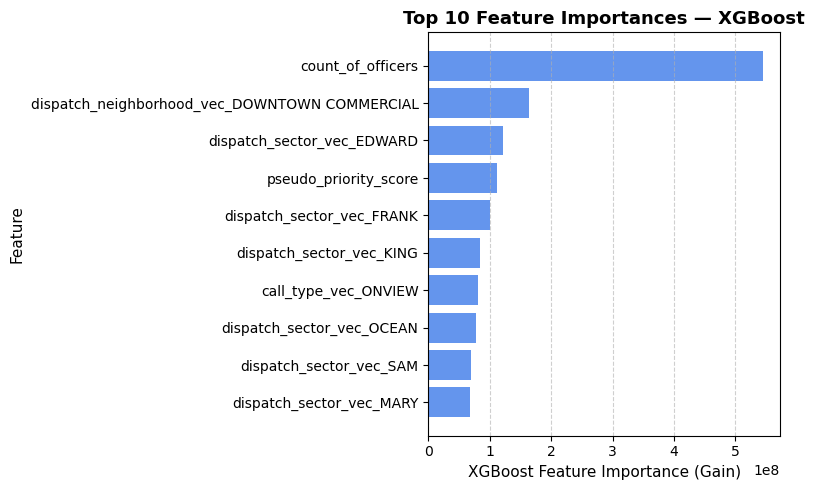

In [10]:
# ============================================================
# 7. Feature Importance Extraction and Plot
# ============================================================
from pyspark.ml.feature import OneHotEncoderModel
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Get metadata names from the features column
feat_name_by_idx = {}
try:
    feat_meta = pred.schema["features"].metadata
    if "ml_attr" in feat_meta and "attrs" in feat_meta["ml_attr"]:
        for k in ("binary", "numeric"):
            for a in feat_meta["ml_attr"]["attrs"].get(k, []):
                feat_name_by_idx[a["idx"]] = a.get("name", f"{k}_{a['idx']}")
except Exception as e:
    print("Could not extract metadata from features column:", e)

# Step 2: Fallback: reconstruct names manually if needed
if not feat_name_by_idx:
    print("Reconstructing feature names using OneHotEncoderModel...")
    ohe_models = [s for s in best_model.stages if isinstance(s, OneHotEncoderModel)]
    assert len(ohe_models) == 1, "Expected a single OneHotEncoderModel stage"
    ohe_model = ohe_models[0]

    cat_vec_cols = ohe_model.getOutputCols()
    cat_sizes = ohe_model.categorySizes
    running_idx = 0

    for col_name, size in zip(cat_vec_cols, cat_sizes):
        for j in range(size):
            feat_name_by_idx[running_idx] = f"{col_name}__{j}"
            running_idx += 1

    for ncol in num_feats:
        feat_name_by_idx[running_idx] = ncol
        running_idx += 1

# Step 3: Extract raw feature importance scores from XGBoost
xgb_stage = best_model.stages[-1]
booster = xgb_stage.get_booster()
raw_imp = booster.get_score(importance_type="gain")  # {'f12': 0.123, ...}

imp_rows = []
for fid, val in raw_imp.items():
    try:
        idx = int(fid[1:])  # remove leading 'f'
        name = feat_name_by_idx.get(idx, fid)
    except Exception:
        name = fid
    imp_rows.append((name, float(val)))

imp_df = (
    pd.DataFrame(imp_rows, columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features:")
print(imp_df.head(10))

# Step 4: Plot top 10 features
topk = 10
plt.figure(figsize=(8, 5))
plt.barh(
    imp_df["feature"].head(topk)[::-1],
    imp_df["importance"].head(topk)[::-1],
    color="cornflowerblue"
)
plt.xlabel("XGBoost Feature Importance (Gain)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Top 10 Feature Importances — XGBoost", fontsize=13, weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(PROJECT_ROOT/ "figures" / "xgb_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()